In [20]:
# Section 1 — Imports and Path Setup

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path('..').resolve()      # notebooks/ → prism_f1/
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'

# Input files
PARENT_CSV = DATA_DIR / 'f1_strategy_dataset_v4.csv'
KAGGLE_TRAIN_CSV = DATA_DIR / 'train.csv'
KAGGLE_TEST_CSV = DATA_DIR / 'test.csv'

# Output pickle files (built in this notebook)
X_TRAIN_PICKLE = DATA_DIR / 'x_train.pkl'
X_TEST_PICKLE = DATA_DIR / 'x_test.pkl'
PARENT_PAIRS_PICKLE = DATA_DIR / 'parent_pairs.pkl'
CONCEPT_GT_PICKLE = DATA_DIR / 'concept_gt.pkl'

# Pandas display settings — show all columns, more rows
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 50)

# Reproducibility
np.random.seed(42)

print(f"Project root:  {PROJECT_ROOT}")
print(f"Data dir:      {DATA_DIR}")
print(f"Parent CSV:    {PARENT_CSV.exists()} — {PARENT_CSV}")
print(f"Kaggle train:  {KAGGLE_TRAIN_CSV.exists()} — {KAGGLE_TRAIN_CSV}")
print(f"Kaggle test:   {KAGGLE_TEST_CSV.exists()} — {KAGGLE_TEST_CSV}")

Project root:  D:\PIT_Stop_predicton\cookbook_prism_f1
Data dir:      D:\PIT_Stop_predicton\cookbook_prism_f1\data
Parent CSV:    True — D:\PIT_Stop_predicton\cookbook_prism_f1\data\f1_strategy_dataset_v4.csv
Kaggle train:  True — D:\PIT_Stop_predicton\cookbook_prism_f1\data\train.csv
Kaggle test:   True — D:\PIT_Stop_predicton\cookbook_prism_f1\data\test.csv


In [3]:
# Section 2 — Load and Inspect the Three Datasets

# Load all three
parent = pd.read_csv(PARENT_CSV)
kaggle_train = pd.read_csv(KAGGLE_TRAIN_CSV)
kaggle_test = pd.read_csv(KAGGLE_TEST_CSV)

# Strip column whitespace defensively (common CSV issue)
parent.columns = parent.columns.str.strip()
kaggle_train.columns = kaggle_train.columns.str.strip()
kaggle_test.columns = kaggle_test.columns.str.strip()

# Basic shape summary
print("=" * 70)
print("DATASET SHAPES")
print("=" * 70)
print(f"Parent dataset:  {parent.shape[0]:>8,} rows × {parent.shape[1]} columns")
print(f"Kaggle train:    {kaggle_train.shape[0]:>8,} rows × {kaggle_train.shape[1]} columns")
print(f"Kaggle test:     {kaggle_test.shape[0]:>8,} rows × {kaggle_test.shape[1]} columns")

# Column-level comparison
print("\n" + "=" * 70)
print("COLUMN COMPARISON")
print("=" * 70)
parent_cols = set(parent.columns)
train_cols = set(kaggle_train.columns)
test_cols = set(kaggle_test.columns)

print(f"\nParent columns ({len(parent_cols)}):")
print(f"  {sorted(parent_cols)}")
print(f"\nKaggle train columns ({len(train_cols)}):")
print(f"  {sorted(train_cols)}")
print(f"\nKaggle test columns ({len(test_cols)}):")
print(f"  {sorted(test_cols)}")

# Differences worth noting
print(f"\nIn parent but NOT in Kaggle train: {sorted(parent_cols - train_cols)}")
print(f"In Kaggle train but NOT in parent: {sorted(train_cols - parent_cols)}")
print(f"In Kaggle train but NOT in test:   {sorted(train_cols - test_cols)}")
print(f"In Kaggle test but NOT in train:   {sorted(test_cols - train_cols)}")

DATASET SHAPES
Parent dataset:   101,371 rows × 16 columns
Kaggle train:     439,140 rows × 16 columns
Kaggle test:      188,165 rows × 15 columns

COLUMN COMPARISON

Parent columns (16):
  ['Compound', 'Cumulative_Degradation', 'Driver', 'LapNumber', 'LapTime (s)', 'LapTime_Delta', 'Normalized_TyreLife', 'PitNextLap', 'PitStop', 'Position', 'Position_Change', 'Race', 'RaceProgress', 'Stint', 'TyreLife', 'Year']

Kaggle train columns (16):
  ['Compound', 'Cumulative_Degradation', 'Driver', 'LapNumber', 'LapTime (s)', 'LapTime_Delta', 'PitNextLap', 'PitStop', 'Position', 'Position_Change', 'Race', 'RaceProgress', 'Stint', 'TyreLife', 'Year', 'id']

Kaggle test columns (15):
  ['Compound', 'Cumulative_Degradation', 'Driver', 'LapNumber', 'LapTime (s)', 'LapTime_Delta', 'PitStop', 'Position', 'Position_Change', 'Race', 'RaceProgress', 'Stint', 'TyreLife', 'Year', 'id']

In parent but NOT in Kaggle train: ['Normalized_TyreLife']
In Kaggle train but NOT in parent: ['id']
In Kaggle train but

In [4]:
# Section 3 — Sample Rows and Dtypes

print("=" * 70)
print("PARENT DATASET — first 3 rows")
print("=" * 70)
print(parent.head(3))

print("\n" + "=" * 70)
print("KAGGLE TRAIN — first 3 rows")
print("=" * 70)
print(kaggle_train.head(3))

print("\n" + "=" * 70)
print("KAGGLE TEST — first 3 rows")
print("=" * 70)
print(kaggle_test.head(3))

# Dtype comparison
print("\n" + "=" * 70)
print("DTYPES")
print("=" * 70)
dtype_compare = pd.DataFrame({
    'parent': parent.dtypes,
    'kaggle_train': kaggle_train.dtypes,
    'kaggle_test': kaggle_test.dtypes,
})
print(dtype_compare)

# Null check
print("\n" + "=" * 70)
print("NULL COUNTS (only non-zero shown)")
print("=" * 70)
for name, df in [('parent', parent), ('kaggle_train', kaggle_train), ('kaggle_test', kaggle_test)]:
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"\n{name}:")
        print(nulls)
    else:
        print(f"\n{name}: no nulls")

# Compound values check
print("\n" + "=" * 70)
print("COMPOUND VALUES")
print("=" * 70)
print(f"Parent:       {sorted(parent['Compound'].dropna().unique())}")
print(f"Kaggle train: {sorted(kaggle_train['Compound'].dropna().unique())}")
print(f"Kaggle test:  {sorted(kaggle_test['Compound'].dropna().unique())}")

# Value ranges for numeric features we care about
print("\n" + "=" * 70)
print("NUMERIC FEATURE RANGES (Kaggle train)")
print("=" * 70)
numeric_cols = ['LapNumber', 'Stint', 'TyreLife', 'Position', 
                'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
                'RaceProgress', 'Position_Change']
print(kaggle_train[numeric_cols].describe().T[['min', 'max', 'mean', 'std']].round(2))

PARENT DATASET — first 3 rows
  Driver  LapNumber Compound  Stint  TyreLife  Position  LapTime (s)                  Race  Year  LapTime_Delta  Cumulative_Degradation  PitStop  PitNextLap  RaceProgress  Normalized_TyreLife  \
0    ALB          1   MEDIUM      1       2.0        17      100.625  Abu Dhabi Grand Prix  2023          0.000                   0.000        0           0      0.017241             0.117647   
1    ALB          2   MEDIUM      1       3.0        18       93.560  Abu Dhabi Grand Prix  2023         -7.065                  -7.065        0           0      0.034483             0.176471   
2    ALB          3   MEDIUM      1       4.0        18       91.768  Abu Dhabi Grand Prix  2023         -1.792                  -8.857        0           0      0.051724             0.235294   

   Position_Change  
0              0.0  
1             -1.0  
2              0.0  

KAGGLE TRAIN — first 3 rows
   id Driver Compound                 Race  Year  PitStop  LapNumber  Stint 

In [12]:
# Section 4 — Outlier Diagnostic + Build the build_x() Function (REVISED)

# ── 4a. Outlier diagnostic: show how many rows are affected by clipping
print("=" * 70)
print("OUTLIER IMPACT — how many rows fall outside clipping bounds")
print("=" * 70)

clip_specs = [
    ('LapTime (s)',            60,    200),
    ('LapTime_Delta',         -60,     60),
    ('Cumulative_Degradation',-250,   250),
    ('Position_Change',        -15,    15),
    ('TyreLife',                 0,    50),
]

for name, df in [('Kaggle train', kaggle_train), ('Kaggle test', kaggle_test), ('Parent', parent)]:
    print(f"\n{name} (n={len(df):,}):")
    for col, lo, hi in clip_specs:
        if col not in df.columns:
            continue
        out_of_range = ((df[col] < lo) | (df[col] > hi)).sum()
        pct = 100 * out_of_range / len(df)
        print(f"  {col:<24s} outside [{lo}, {hi}]: {out_of_range:>6,} rows ({pct:.2f}%)")


# ── 4b. The build_x function

FEATURE_NAMES = [
    'lap_time_norm',          # 0
    'lap_time_delta',         # 1
    'cumulative_degradation', # 2
    'tyre_life_norm',         # 3
    'compound_soft',          # 4
    'compound_medium',        # 5
    'compound_hard',          # 6
    'compound_inter',         # 7
    'compound_wet',           # 8
    'position_norm',          # 9
    'position_change_norm',   # 10
    'race_progress',          # 11
    'stint_norm',             # 12
]

COMPOUND_TO_IDX = {
    'SOFT': 4, 'MEDIUM': 5, 'HARD': 6, 'INTERMEDIATE': 7, 'WET': 8,
}


def build_x(df: pd.DataFrame) -> np.ndarray:
    """
    Build the 13-dimensional input feature vector for each row of `df`.
    
    Returns a numpy array of shape (n_rows, 13).
    Operates vectorized over the full dataframe — no per-row loops.
    """
    n = len(df)
    x = np.zeros((n, 13), dtype=np.float32)
    
    # 0. lap_time_norm — clip then simple normalization
    # Subtract typical F1 lap time (90s), divide by typical range (30s)
    # Result is approximately in [-1, +1] for normal laps
    x[:, 0] = (df['LapTime (s)'].clip(60, 200).values - 90.0) / 30.0
    
    # 1. lap_time_delta — clip then divide by 10
    x[:, 1] = df['LapTime_Delta'].clip(-60, 60).values / 10.0
    
    # 2. cumulative_degradation — clip then divide by 250
    x[:, 2] = df['Cumulative_Degradation'].clip(-250, 250).values / 250.0
    
    # 3. tyre_life_norm — divide by 50, clip to [0, 1]
    x[:, 3] = (df['TyreLife'].values / 50.0).clip(0, 1)
    
    # 4–8. Compound one-hot
    compounds = df['Compound'].values
    for i, c in enumerate(compounds):
        idx = COMPOUND_TO_IDX.get(c)
        if idx is not None:
            x[i, idx] = 1.0
    
    # 9. position_norm — divide by 20
    x[:, 9] = df['Position'].values / 20.0
    
    # 10. position_change_norm — clip to [-15, 15] then divide by 7.5
    x[:, 10] = df['Position_Change'].astype(float).clip(-15, 15).values / 7.5
    
    # 11. race_progress — already in [0, 1]
    x[:, 11] = df['RaceProgress'].values
    
    # 12. stint_norm — divide by 8
    x[:, 12] = df['Stint'].values / 8.0
    
    return x


# ── 4c. Smoke-test on a small sample
print("\n" + "=" * 70)
print("BUILD_X SMOKE TEST")
print("=" * 70)

sample = kaggle_train.head(5)
x_sample = build_x(sample)

print(f"Input shape:  {sample.shape}")
print(f"Output shape: {x_sample.shape}")
print(f"Output dtype: {x_sample.dtype}")
print(f"\nFeature values for first row (D109, Canadian GP 2022, HARD, TyreLife=39):")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  [{i:>2}] {name:<26s} = {x_sample[0, i]:+.4f}")

print(f"\nRaw input values for first row (for verification):")
print(sample.iloc[0])

# ── 4d. Verify no NaN / Inf in output
print("\n" + "=" * 70)
print("SANITY CHECKS")
print("=" * 70)
print(f"Any NaN in x_sample?  {np.isnan(x_sample).any()}")
print(f"Any Inf in x_sample?  {np.isinf(x_sample).any()}")
print(f"Value range in x_sample: [{x_sample.min():.4f}, {x_sample.max():.4f}]")

OUTLIER IMPACT — how many rows fall outside clipping bounds

Kaggle train (n=439,140):
  LapTime (s)              outside [60, 200]:     37 rows (0.01%)
  LapTime_Delta            outside [-60, 60]:    617 rows (0.14%)
  Cumulative_Degradation   outside [-250, 250]:    677 rows (0.15%)
  Position_Change          outside [-15, 15]:    586 rows (0.13%)
  TyreLife                 outside [0, 50]:  1,381 rows (0.31%)

Kaggle test (n=188,165):
  LapTime (s)              outside [60, 200]:     17 rows (0.01%)
  LapTime_Delta            outside [-60, 60]:    275 rows (0.15%)
  Cumulative_Degradation   outside [-250, 250]:    259 rows (0.14%)
  Position_Change          outside [-15, 15]:    284 rows (0.15%)
  TyreLife                 outside [0, 50]:    619 rows (0.33%)

Parent (n=101,371):
  LapTime (s)              outside [60, 200]:     32 rows (0.03%)
  LapTime_Delta            outside [-60, 60]:    469 rows (0.46%)
  Cumulative_Degradation   outside [-250, 250]:    337 rows (0.33%)
  Posi

LapTime_Delta DISTRIBUTION INSPECTION

Full distribution (Kaggle train, n=439,140):
  min:      -2403.89
  p0.1%:      -63.24
  p1%:        -40.26
  p5%:        -24.82
  p25%:        -8.88
  p50%:        -0.29
  p75%:         0.12
  p95%:        19.03
  p99%:        30.93
  p99.9%:      49.36
  max:       2423.93

Of the 21,568 rows with |LapTime_Delta| > 30:
  Of those, |delta| in (30, 50]:    19,715
  Of those, |delta| in (50, 100]:    1,633
  Of those, |delta| in (100, 500]:      82
  Of those, |delta| > 500:             138


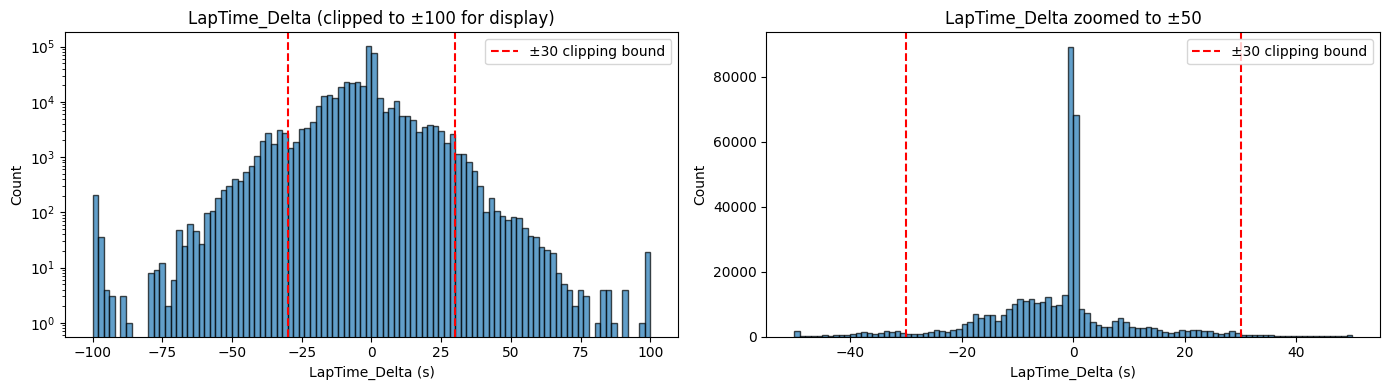

In [8]:
# Diagnostic: examine the LapTime_Delta distribution beyond ±30

print("=" * 70)
print("LapTime_Delta DISTRIBUTION INSPECTION")
print("=" * 70)

# Percentiles across the full Kaggle train
deltas = kaggle_train['LapTime_Delta']
print(f"\nFull distribution (Kaggle train, n={len(deltas):,}):")
print(f"  min:    {deltas.min():>10.2f}")
print(f"  p0.1%:  {deltas.quantile(0.001):>10.2f}")
print(f"  p1%:    {deltas.quantile(0.01):>10.2f}")
print(f"  p5%:    {deltas.quantile(0.05):>10.2f}")
print(f"  p25%:   {deltas.quantile(0.25):>10.2f}")
print(f"  p50%:   {deltas.quantile(0.50):>10.2f}")
print(f"  p75%:   {deltas.quantile(0.75):>10.2f}")
print(f"  p95%:   {deltas.quantile(0.95):>10.2f}")
print(f"  p99%:   {deltas.quantile(0.99):>10.2f}")
print(f"  p99.9%: {deltas.quantile(0.999):>10.2f}")
print(f"  max:    {deltas.max():>10.2f}")

# Where do the "outliers" (|delta| > 30) actually live?
outliers = deltas[deltas.abs() > 30]
print(f"\nOf the {len(outliers):,} rows with |LapTime_Delta| > 30:")
print(f"  Of those, |delta| in (30, 50]:    {((outliers.abs() > 30) & (outliers.abs() <= 50)).sum():>6,}")
print(f"  Of those, |delta| in (50, 100]:   {((outliers.abs() > 50) & (outliers.abs() <= 100)).sum():>6,}")
print(f"  Of those, |delta| in (100, 500]:  {((outliers.abs() > 100) & (outliers.abs() <= 500)).sum():>6,}")
print(f"  Of those, |delta| > 500:          {(outliers.abs() > 500).sum():>6,}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full distribution
axes[0].hist(deltas.clip(-100, 100), bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(-30, color='red', linestyle='--', label='±30 clipping bound')
axes[0].axvline(30, color='red', linestyle='--')
axes[0].set_title('LapTime_Delta (clipped to ±100 for display)')
axes[0].set_xlabel('LapTime_Delta (s)')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
axes[0].legend()

# Right: zoom in on the moderate range
axes[1].hist(deltas.clip(-50, 50), bins=100, edgecolor='black', alpha=0.7)
axes[1].axvline(-30, color='red', linestyle='--', label='±30 clipping bound')
axes[1].axvline(30, color='red', linestyle='--')
axes[1].set_title('LapTime_Delta zoomed to ±50')
axes[1].set_xlabel('LapTime_Delta (s)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

Position_Change DISTRIBUTION INSPECTION

Full distribution (Kaggle train, n=439,140):
  min:        -18.00
  p0.1%:      -15.00
  p1%:        -11.00
  p5%:         -7.00
  p25%:        -1.00
  p50%:         0.00
  p75%:         2.00
  p95%:         7.00
  p99%:        11.00
  p99.9%:      14.00
  max:         18.00

Of the 10,910 rows with |Position_Change| > 10:
  |val| in (10, 15]:   10,324
  |val| in (15, 20]:      586
  |val| > 20:               0

TyreLife DISTRIBUTION INSPECTION

Full distribution (Kaggle train, n=439,140):
  min:          1.00
  p0.1%:        1.00
  p1%:          1.00
  p5%:          2.00
  p25%:         6.00
  p50%:        12.00
  p75%:        20.00
  p95%:        32.00
  p99%:        43.00
  p99.9%:      61.00
  max:         77.00

Of the 6,661 rows with TyreLife > 40:
  val in (40, 50]:   5,280
  val in (50, 60]:     909
  val > 60:            472



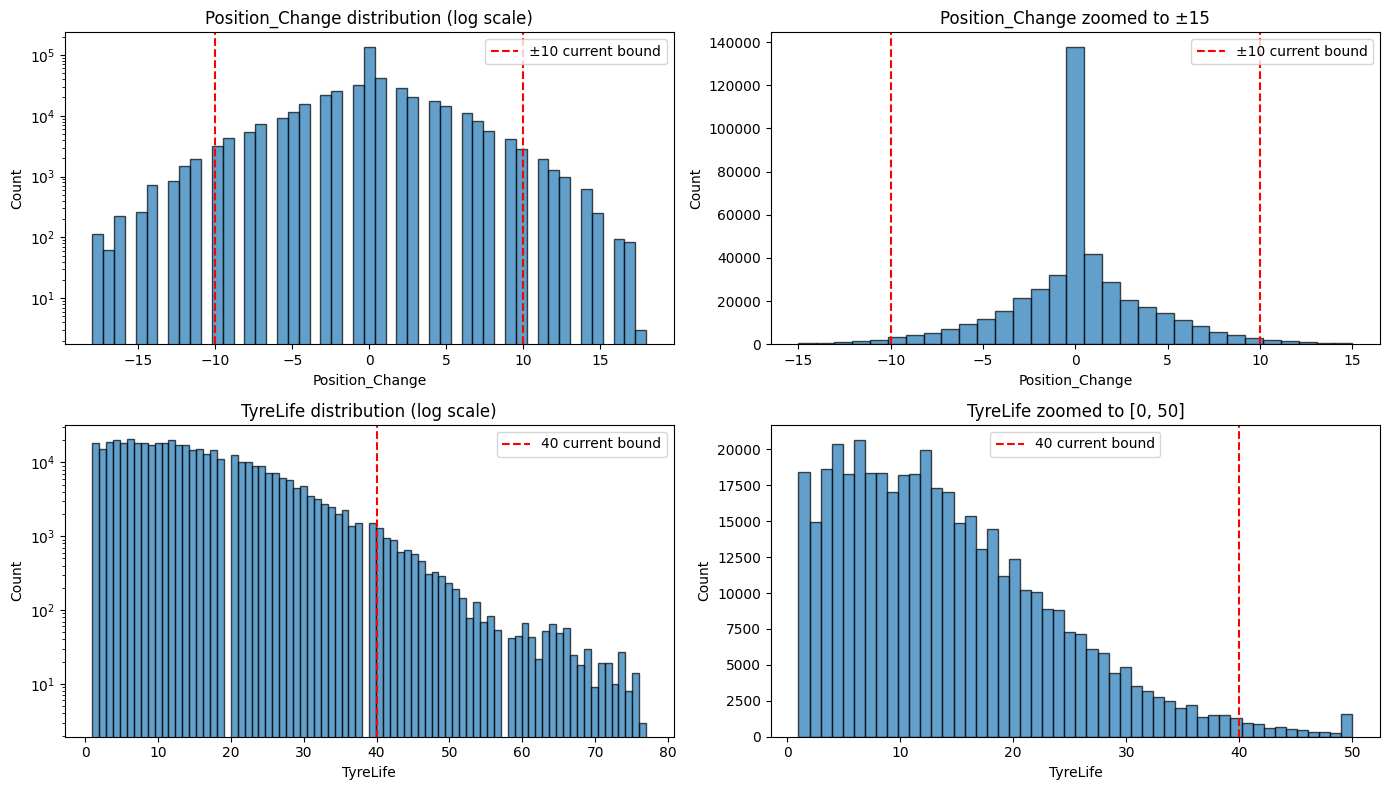

In [11]:
# Diagnostic: examine Position_Change and TyreLife distributions

for col, current_lo, current_hi in [('Position_Change', -10, 10), ('TyreLife', 0, 40)]:
    print("=" * 70)
    print(f"{col} DISTRIBUTION INSPECTION")
    print("=" * 70)
    
    series = kaggle_train[col].astype(float)
    
    print(f"\nFull distribution (Kaggle train, n={len(series):,}):")
    print(f"  min:    {series.min():>10.2f}")
    print(f"  p0.1%:  {series.quantile(0.001):>10.2f}")
    print(f"  p1%:    {series.quantile(0.01):>10.2f}")
    print(f"  p5%:    {series.quantile(0.05):>10.2f}")
    print(f"  p25%:   {series.quantile(0.25):>10.2f}")
    print(f"  p50%:   {series.quantile(0.50):>10.2f}")
    print(f"  p75%:   {series.quantile(0.75):>10.2f}")
    print(f"  p95%:   {series.quantile(0.95):>10.2f}")
    print(f"  p99%:   {series.quantile(0.99):>10.2f}")
    print(f"  p99.9%: {series.quantile(0.999):>10.2f}")
    print(f"  max:    {series.max():>10.2f}")
    
    # For Position_Change, look at how outliers are distributed beyond ±10
    # For TyreLife, look at how outliers are distributed beyond 40
    if col == 'Position_Change':
        outliers = series[series.abs() > current_hi]
        print(f"\nOf the {len(outliers):,} rows with |{col}| > {current_hi}:")
        print(f"  |val| in (10, 15]:   {((outliers.abs() > 10) & (outliers.abs() <= 15)).sum():>6,}")
        print(f"  |val| in (15, 20]:   {((outliers.abs() > 15) & (outliers.abs() <= 20)).sum():>6,}")
        print(f"  |val| > 20:          {(outliers.abs() > 20).sum():>6,}")
    else:  # TyreLife
        outliers = series[series > current_hi]
        print(f"\nOf the {len(outliers):,} rows with {col} > {current_hi}:")
        print(f"  val in (40, 50]:  {((outliers > 40) & (outliers <= 50)).sum():>6,}")
        print(f"  val in (50, 60]:  {((outliers > 50) & (outliers <= 60)).sum():>6,}")
        print(f"  val > 60:         {(outliers > 60).sum():>6,}")
    
    print()


# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Position_Change: full and zoomed
pc = kaggle_train['Position_Change'].astype(float)
axes[0, 0].hist(pc.clip(-25, 25), bins=51, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(-10, color='red', linestyle='--', label='±10 current bound')
axes[0, 0].axvline(10, color='red', linestyle='--')
axes[0, 0].set_title('Position_Change distribution (log scale)')
axes[0, 0].set_xlabel('Position_Change')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()

axes[0, 1].hist(pc.clip(-15, 15), bins=31, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(-10, color='red', linestyle='--', label='±10 current bound')
axes[0, 1].axvline(10, color='red', linestyle='--')
axes[0, 1].set_title('Position_Change zoomed to ±15')
axes[0, 1].set_xlabel('Position_Change')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# TyreLife: full and zoomed
tl = kaggle_train['TyreLife']
axes[1, 0].hist(tl.clip(0, 80), bins=80, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(40, color='red', linestyle='--', label='40 current bound')
axes[1, 0].set_title('TyreLife distribution (log scale)')
axes[1, 0].set_xlabel('TyreLife')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

axes[1, 1].hist(tl.clip(0, 50), bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(40, color='red', linestyle='--', label='40 current bound')
axes[1, 1].set_title('TyreLife zoomed to [0, 50]')
axes[1, 1].set_xlabel('TyreLife')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Section 5 — Build the 6 Concept Ground Truth Functions

# ── 5a. Compound cliff reference values (pedagogical, not physical priors)
CLIFF_REF = {
    'SOFT': 18, 'MEDIUM': 22, 'HARD': 30,
    'INTERMEDIATE': 20, 'WET': 25,
}

# Typical pit windows per compound (race_progress fractions)
TYPICAL_WINDOWS = {
    'SOFT':         [(0.20, 0.35), (0.55, 0.70)],
    'MEDIUM':       [(0.30, 0.50), (0.60, 0.80)],
    'HARD':         [(0.40, 0.65)],
    'INTERMEDIATE': [(0.10, 0.90)],
    'WET':          [(0.10, 0.90)],
}

CONCEPT_NAMES = [
    'degradation_severity',
    'pace_decay_rate',
    'strategic_window',
    'track_position_risk',
    'undercut_pressure',
    'endgame_proximity',
]


def degradation_severity(tyre_life: np.ndarray, compound: np.ndarray) -> np.ndarray:
    """How worn is the tyre relative to its compound's cliff?
    Returns array of values in [0, 1].
    """
    cliff = np.array([CLIFF_REF.get(c, 25) for c in compound], dtype=np.float32)
    tl = tyre_life.astype(np.float32)
    
    result = np.zeros_like(tl)
    
    # Below half-cliff: no degradation
    mask_low = tl <= cliff * 0.5
    
    # Between half-cliff and cliff: linear ramp from 0 to 0.6
    mask_mid = (tl > cliff * 0.5) & (tl <= cliff)
    result[mask_mid] = (tl[mask_mid] - cliff[mask_mid] * 0.5) / (cliff[mask_mid] * 0.5) * 0.6
    
    # Beyond cliff: 0.6 → 1.0 over the next 10 laps
    mask_high = tl > cliff
    result[mask_high] = np.minimum(1.0, 0.6 + (tl[mask_high] - cliff[mask_high]) / 10.0 * 0.4)
    
    return result


def pace_decay_rate(lap_time_delta: np.ndarray, cumulative_degradation: np.ndarray) -> np.ndarray:
    """Combined signal: recent lap-to-lap change + accumulated stint degradation.
    Returns array of values in [0, 1].
    """
    # Clip to plausible ranges first (matches build_x clipping bounds)
    delta = np.clip(lap_time_delta, -60, 60)
    cumdeg = np.clip(cumulative_degradation, -250, 250)
    
    # Recent decay: positive delta = slower lap = decay signal
    recent = np.clip(delta / 2.0, 0, 1) * 0.5
    
    # Accumulated decay: large positive cumulative_degradation = lots of pace lost
    accum = np.clip(cumdeg / 50.0, 0, 1) * 0.5
    
    return (recent + accum).astype(np.float32)


def strategic_window(race_progress: np.ndarray, compound: np.ndarray) -> np.ndarray:
    """How close are we to the typical pit window for this compound?
    Returns array of values in [0, 1].
    """
    n = len(race_progress)
    result = np.zeros(n, dtype=np.float32)
    
    for i in range(n):
        rp = race_progress[i]
        comp = compound[i]
        windows = TYPICAL_WINDOWS.get(comp, [(0.3, 0.7)])
        
        best = 0.0
        for lo, hi in windows:
            if lo <= rp <= hi:
                mid = (lo + hi) / 2.0
                score = 1.0 - 2.0 * abs(rp - mid) / (hi - lo)
                best = max(best, score)
        result[i] = best
    
    return result


def track_position_risk(position: np.ndarray, position_change: np.ndarray) -> np.ndarray:
    """How risky is pitting from a track-position standpoint?
    High when in the points AND recently losing positions.
    Returns array of values in [0, 1].
    """
    pos = position.astype(np.float32)
    pc = position_change.astype(np.float32)
    
    in_points = (pos <= 10).astype(np.float32)
    losing_pos = np.clip(np.maximum(0, pc) / 3.0, 0, 1)
    
    return in_points * (0.5 + 0.5 * losing_pos)


def undercut_pressure(position_change: np.ndarray, race_progress: np.ndarray) -> np.ndarray:
    """Proxy: are we mid-race AND losing positions (suggests undercut threat)?
    Returns array of values in [0, 1].
    """
    pc = position_change.astype(np.float32)
    rp = race_progress.astype(np.float32)
    
    in_mid_race = ((rp >= 0.2) & (rp <= 0.85)).astype(np.float32)
    losing_pos = np.clip(np.maximum(0, pc) / 2.0, 0, 1)
    
    return in_mid_race * losing_pos


def endgame_proximity(race_progress: np.ndarray) -> np.ndarray:
    """How close to race end? Anti-pit signal.
    Returns array of values in [0, 1], zero until race_progress > 0.85.
    """
    rp = race_progress.astype(np.float32)
    return np.clip((rp - 0.85) / 0.15, 0, 1)


def build_concept_gt(df: pd.DataFrame) -> np.ndarray:
    """Build the 6-dimensional concept ground truth vector for each row.
    Returns array of shape (n_rows, 6), all values in [0, 1].
    """
    tyre_life = df['TyreLife'].values
    compound = df['Compound'].fillna('MEDIUM').values   # default to MEDIUM for nulls
    lap_time_delta = df['LapTime_Delta'].values
    cumdeg = df['Cumulative_Degradation'].values
    race_progress = df['RaceProgress'].values
    position = df['Position'].values
    position_change = df['Position_Change'].values
    
    n = len(df)
    c = np.zeros((n, 6), dtype=np.float32)
    
    c[:, 0] = degradation_severity(tyre_life, compound)
    c[:, 1] = pace_decay_rate(lap_time_delta, cumdeg)
    c[:, 2] = strategic_window(race_progress, compound)
    c[:, 3] = track_position_risk(position, position_change)
    c[:, 4] = undercut_pressure(position_change, race_progress)
    c[:, 5] = endgame_proximity(race_progress)
    
    return c


# ── 5b. Smoke test on the same 5 rows
print("=" * 70)
print("BUILD_CONCEPT_GT SMOKE TEST")
print("=" * 70)

sample = kaggle_train.head(5)
c_sample = build_concept_gt(sample)

print(f"Input shape:  {sample.shape}")
print(f"Output shape: {c_sample.shape}")
print(f"Output dtype: {c_sample.dtype}")
print(f"\nConcept values per sample row:\n")

# Print as a table
print(f"{'row':>3} | {'driver':<6} | {'compound':<10} | {'tl':>4} | {'rp':>5} | {'pos':>4} | {'pc':>4} | ", end='')
print(' | '.join(f"{name:<10}"[:10] for name in CONCEPT_NAMES))
print("-" * 130)
for i in range(5):
    r = sample.iloc[i]
    print(f"{i:>3} | {r['Driver']:<6} | {r['Compound']:<10} | {r['TyreLife']:>4.0f} | {r['RaceProgress']:>5.2f} | {r['Position']:>4} | {r['Position_Change']:>4} | ", end='')
    print(' | '.join(f"{c_sample[i, j]:>10.4f}" for j in range(6)))


# ── 5c. Sanity checks
print("\n" + "=" * 70)
print("SANITY CHECKS")
print("=" * 70)
print(f"Any NaN in c_sample?     {np.isnan(c_sample).any()}")
print(f"Any value < 0?           {(c_sample < 0).any()}")
print(f"Any value > 1?           {(c_sample > 1).any()}")
print(f"Value range:             [{c_sample.min():.4f}, {c_sample.max():.4f}]")


# ── 5d. Sanity check on full dataset (does it run, do values look reasonable in aggregate?)
print("\n" + "=" * 70)
print("FULL DATASET CONCEPT GT DISTRIBUTIONS (Kaggle train)")
print("=" * 70)
c_full = build_concept_gt(kaggle_train)

for j, name in enumerate(CONCEPT_NAMES):
    vals = c_full[:, j]
    print(f"  {name:<22s}  mean={vals.mean():.3f}  std={vals.std():.3f}  "
          f"frac>0={np.mean(vals > 0):.2%}  frac>0.5={np.mean(vals > 0.5):.2%}")

BUILD_CONCEPT_GT SMOKE TEST
Input shape:  (5, 16)
Output shape: (5, 6)
Output dtype: float32

Concept values per sample row:

row | driver | compound   |   tl |    rp |  pos |   pc | degradatio | pace_decay | strategic_ | track_posi | undercut_p | endgame_pr
----------------------------------------------------------------------------------------------------------------------------------
  0 | D109   | HARD       |   39 |  0.71 |    8 |    5 |     0.9600 |     0.2102 |     0.0000 |     1.0000 |     1.0000 |     0.0000
  1 | D086   | HARD       |    7 |  0.35 |    4 |   -3 |     0.0000 |     0.0000 |     0.0000 |     0.5000 |     0.0000 |     0.0000
  2 | ZON    | HARD       |   22 |  0.82 |   13 |    3 |     0.2800 |     0.0000 |     0.0000 |     0.0000 |     1.0000 |     0.0000
  3 | SPE    | MEDIUM     |    2 |  0.08 |    7 |    0 |     0.0000 |     0.0000 |     0.0000 |     0.5000 |     0.0000 |     0.0000
  4 | D019   | HARD       |    6 |  0.36 |    2 |    3 |     0.0000 |     0.50

DISTRIBUTION COMPARISON: parent dataset vs Kaggle train

Feature                  | Source         |     mean |      std |       p1 |      p50 |      p99
----------------------------------------------------------------------------------------------------
TyreLife                 | parent         |    14.50 |    10.10 |     1.00 |    13.00 |    45.00
                         | kaggle_train   |    14.13 |     9.68 |     1.00 |    12.00 |    43.00

LapTime (s)              | parent         |    92.22 |    14.05 |    70.18 |    91.17 |   139.84
                         | kaggle_train   |    90.84 |    11.48 |    70.72 |    90.52 |   124.90

LapTime_Delta            | parent         |    -0.21 |    15.72 |   -44.44 |    -0.03 |    44.84
                         | kaggle_train   |    -3.15 |    12.58 |   -40.26 |    -0.29 |    30.93
                         | >>>            | mean diverges by 1433%

Cumulative_Degradation   | parent         |   -29.85 |    63.32 |  -217.99 |   -21.68 |   124

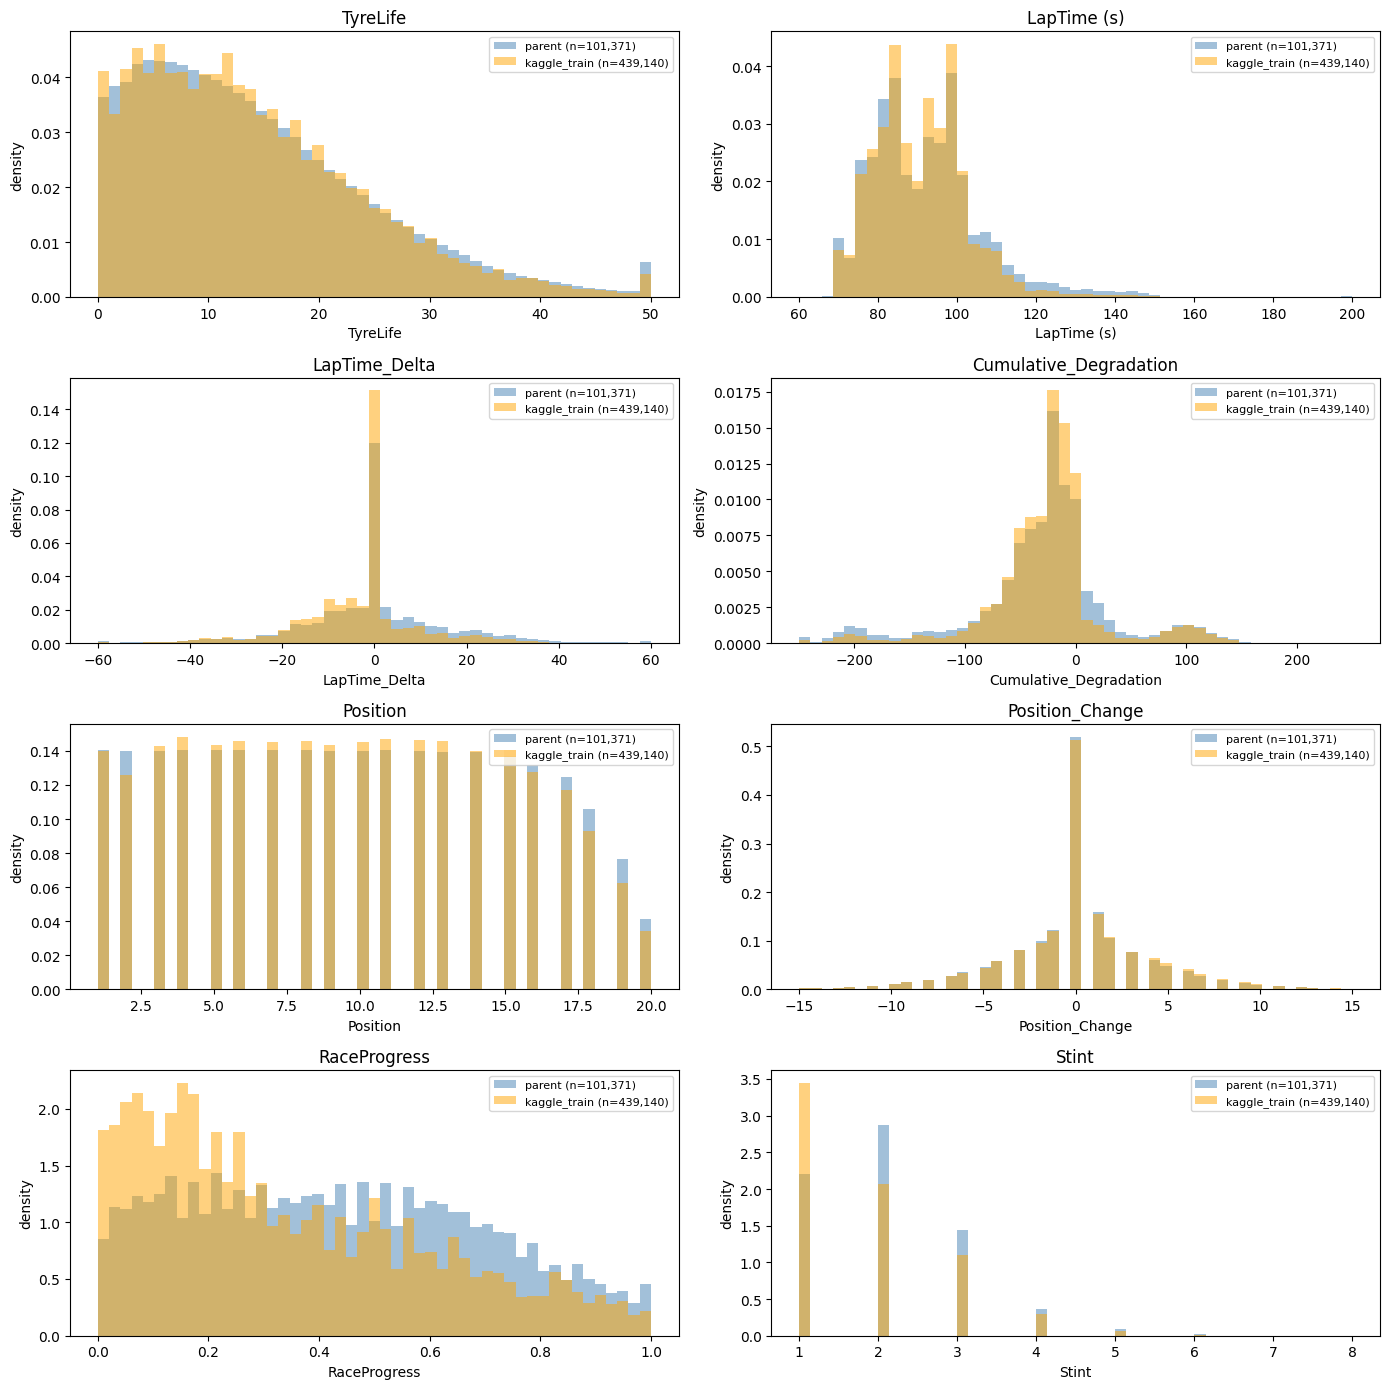

In [14]:
# Section 6 — Parent vs Kaggle Train Distribution Comparison

print("=" * 70)
print("DISTRIBUTION COMPARISON: parent dataset vs Kaggle train")
print("=" * 70)

# Features to compare (the ones that feed into the model)
features_to_compare = [
    ('TyreLife',                  0, 50),
    ('LapTime (s)',              60, 200),
    ('LapTime_Delta',           -60, 60),
    ('Cumulative_Degradation', -250, 250),
    ('Position',                  1, 20),
    ('Position_Change',         -15, 15),
    ('RaceProgress',              0, 1),
    ('Stint',                     1, 8),
]

# Table-form summary comparison
print(f"\n{'Feature':<24s} | {'Source':<14s} | {'mean':>8s} | {'std':>8s} | {'p1':>8s} | {'p50':>8s} | {'p99':>8s}")
print("-" * 100)
for feat, lo, hi in features_to_compare:
    if feat not in parent.columns or feat not in kaggle_train.columns:
        continue
    p = parent[feat].clip(lo, hi).dropna()
    k = kaggle_train[feat].clip(lo, hi).dropna()
    print(f"{feat:<24s} | {'parent':<14s} | {p.mean():>8.2f} | {p.std():>8.2f} | {p.quantile(0.01):>8.2f} | {p.quantile(0.50):>8.2f} | {p.quantile(0.99):>8.2f}")
    print(f"{'':<24s} | {'kaggle_train':<14s} | {k.mean():>8.2f} | {k.std():>8.2f} | {k.quantile(0.01):>8.2f} | {k.quantile(0.50):>8.2f} | {k.quantile(0.99):>8.2f}")
    # Highlight large differences
    mean_diff_pct = abs(p.mean() - k.mean()) / (abs(p.mean()) + 1e-6) * 100
    if mean_diff_pct > 20:
        print(f"{'':<24s} | {'>>>':<14s} | mean diverges by {mean_diff_pct:.0f}%")
    print()


# Compound distribution comparison
print("\n" + "=" * 70)
print("COMPOUND DISTRIBUTION")
print("=" * 70)
for name, df in [('parent', parent), ('kaggle_train', kaggle_train)]:
    print(f"\n{name}:")
    print(df['Compound'].value_counts(normalize=True).sort_index().round(3))


# Class balance check
print("\n" + "=" * 70)
print("CLASS BALANCE (PitNextLap)")
print("=" * 70)
for name, df in [('parent', parent), ('kaggle_train', kaggle_train)]:
    pos = (df['PitNextLap'] == 1).sum()
    total = len(df)
    print(f"  {name:<14s}: PitNextLap=1 in {pos:,}/{total:,} rows = {pos/total*100:.2f}%")


# Visual comparison — overlay histograms for each feature
print("\n" + "=" * 70)
print("VISUAL OVERLAYS (parent vs kaggle_train)")
print("=" * 70)

n_features = len(features_to_compare)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = axes.flatten()

for idx, (feat, lo, hi) in enumerate(features_to_compare):
    if feat not in parent.columns or feat not in kaggle_train.columns:
        continue
    ax = axes[idx]
    p_vals = parent[feat].clip(lo, hi).dropna()
    k_vals = kaggle_train[feat].clip(lo, hi).dropna()
    
    bins = np.linspace(lo, hi, 50)
    ax.hist(p_vals, bins=bins, alpha=0.5, density=True, label=f'parent (n={len(p_vals):,})', color='steelblue')
    ax.hist(k_vals, bins=bins, alpha=0.5, density=True, label=f'kaggle_train (n={len(k_vals):,})', color='orange')
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel('density')
    ax.legend(fontsize=8)

# Hide any unused subplots
for idx in range(len(features_to_compare), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [21]:
# Section 7 — Build the Stage 1 Training Pairs (Parent Dataset)

print("=" * 70)
print("BUILDING STAGE 1 PAIRS — parent dataset, same-stint consecutive laps")
print("=" * 70)

# Sort to ensure consecutive laps are adjacent
parent_sorted = parent.sort_values(
    ['Driver', 'Race', 'Year', 'Stint', 'LapNumber']
).reset_index(drop=True)

# Within each (Driver, Race, Year, Stint) group, compute the next row's features
# using groupby shift
group_keys = ['Driver', 'Race', 'Year', 'Stint']

# Target features for the Imagination (5 outputs)
target_features = [
    'LapTime (s)',             # → ŷ_lap_time
    'LapTime_Delta',           # → ŷ_lap_time_delta
    'TyreLife',                # → ŷ_tyre_life
    'Position_Change',         # → ŷ_position_change
    'Cumulative_Degradation',  # → ŷ_cumulative_degradation
]

# Shift each target feature within group by -1 to get the next row's value
for feat in target_features:
    target_col = f'next_{feat}'
    parent_sorted[target_col] = parent_sorted.groupby(group_keys)[feat].shift(-1)

# Also check that the LapNumber actually increments by 1 (sanity check)
parent_sorted['next_LapNumber'] = parent_sorted.groupby(group_keys)['LapNumber'].shift(-1)
parent_sorted['lap_step'] = parent_sorted['next_LapNumber'] - parent_sorted['LapNumber']

# Now filter: keep only rows where the next row exists (not last lap of stint)
# AND is the immediate next lap (lap_step == 1)
print(f"\nParent sorted rows:                       {len(parent_sorted):,}")

mask_has_next = parent_sorted['next_LapNumber'].notna()
print(f"After dropping last-row-of-stint:         {mask_has_next.sum():,}")

mask_consecutive = parent_sorted['lap_step'] == 1
print(f"After requiring lap_step == 1:            {(mask_has_next & mask_consecutive).sum():,}")

# Also drop rows with missing Compound (66 rows in parent)
mask_compound = parent_sorted['Compound'].notna()
print(f"After dropping null Compound:             {(mask_has_next & mask_consecutive & mask_compound).sum():,}")

valid_pairs = parent_sorted[mask_has_next & mask_consecutive & mask_compound].copy()

# Drop the helper columns
valid_pairs = valid_pairs.drop(columns=['next_LapNumber', 'lap_step'])

print(f"\nFinal stage-1 pairs:                      {len(valid_pairs):,}")
print(f"  Fraction of parent that became a pair:  {len(valid_pairs)/len(parent)*100:.1f}%")


# Show what the pair structure looks like
print("\n" + "=" * 70)
print("SAMPLE PAIR (first row of valid_pairs)")
print("=" * 70)
first_pair = valid_pairs.iloc[0]
print(f"\nCurrent row features (will go through build_x):")
print(f"  Driver={first_pair['Driver']}, Race={first_pair['Race']}, Year={first_pair['Year']}")
print(f"  LapNumber={first_pair['LapNumber']}, Stint={first_pair['Stint']}, Compound={first_pair['Compound']}")
print(f"  TyreLife={first_pair['TyreLife']}, LapTime={first_pair['LapTime (s)']:.3f}, Position={first_pair['Position']}")

print(f"\nNext-row targets (Imagination predicts these):")
for feat in target_features:
    val = first_pair[f'next_{feat}']
    print(f"  next_{feat:<22s} = {val:.3f}")


# Save to pickle (avoids pyarrow version conflict)
valid_pairs.to_pickle(PARENT_PAIRS_PICKLE)
print(f"\nSaved to: {PARENT_PAIRS_PICKLE}")


# Quick stats on the target features
print("\n" + "=" * 70)
print("TARGET FEATURE STATISTICS (what the Imagination must predict)")
print("=" * 70)
for feat in target_features:
    col = f'next_{feat}'
    s = valid_pairs[col]
    print(f"  next_{feat:<22s}  mean={s.mean():>8.2f}  std={s.std():>8.2f}  min={s.min():>8.2f}  max={s.max():>8.2f}")

BUILDING STAGE 1 PAIRS — parent dataset, same-stint consecutive laps

Parent sorted rows:                       101,371
After dropping last-row-of-stint:         96,252
After requiring lap_step == 1:            95,869
After dropping null Compound:             95,805

Final stage-1 pairs:                      95,805
  Fraction of parent that became a pair:  94.5%

SAMPLE PAIR (first row of valid_pairs)

Current row features (will go through build_x):
  Driver=ALB, Race=Abu Dhabi Grand Prix, Year=2023
  LapNumber=1, Stint=1, Compound=MEDIUM
  TyreLife=2.0, LapTime=100.625, Position=17

Next-row targets (Imagination predicts these):
  next_LapTime (s)            = 93.560
  next_LapTime_Delta          = -7.065
  next_TyreLife               = 3.000
  next_Position_Change        = -1.000
  next_Cumulative_Degradation = -7.065

Saved to: D:\PIT_Stop_predicton\cookbook_prism_f1\data\parent_pairs.pkl

TARGET FEATURE STATISTICS (what the Imagination must predict)
  next_LapTime (s)             m

In [22]:
# Section 8 — Build and Save the Kaggle Feature/Concept Tensors

print("=" * 70)
print("BUILDING KAGGLE FEATURE TENSORS")
print("=" * 70)

# ── 8a. Kaggle train: x vector + concept GT + target ─────────────
print("\nProcessing Kaggle train...")
x_train_arr = build_x(kaggle_train)
c_train_arr = build_concept_gt(kaggle_train)

# Wrap into a single dataframe for storage
# We carry the id, x features (13 cols), concept GT (6 cols), and target
x_train_cols = [f'x_{name}' for name in FEATURE_NAMES]
c_train_cols = [f'c_{name}' for name in CONCEPT_NAMES]

train_out = pd.DataFrame(
    np.concatenate([x_train_arr, c_train_arr], axis=1),
    columns=x_train_cols + c_train_cols,
)
train_out['id'] = kaggle_train['id'].values
train_out['PitNextLap'] = kaggle_train['PitNextLap'].values

# Reorder: id, x_*, c_*, target
train_out = train_out[['id'] + x_train_cols + c_train_cols + ['PitNextLap']]

print(f"  x_train shape:    {x_train_arr.shape}")
print(f"  c_train shape:    {c_train_arr.shape}")
print(f"  Output df shape:  {train_out.shape}")
print(f"  Columns:          {len(train_out.columns)}  (1 id + 13 x + 6 c + 1 target)")


# ── 8b. Kaggle test: x vector only ─────────────────────────────────
print("\nProcessing Kaggle test...")
x_test_arr = build_x(kaggle_test)

x_test_cols = [f'x_{name}' for name in FEATURE_NAMES]
test_out = pd.DataFrame(x_test_arr, columns=x_test_cols)
test_out['id'] = kaggle_test['id'].values

# Reorder: id, x_*
test_out = test_out[['id'] + x_test_cols]

print(f"  x_test shape:     {x_test_arr.shape}")
print(f"  Output df shape:  {test_out.shape}")


# ── 8c. Sanity checks ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("SANITY CHECKS")
print("=" * 70)

# No NaN, no Inf
print(f"\nKaggle train output:")
print(f"  Any NaN?           {train_out[x_train_cols + c_train_cols].isna().any().any()}")
print(f"  Any Inf?           {np.isinf(train_out[x_train_cols + c_train_cols].values).any()}")
print(f"  PitNextLap dtype:  {train_out['PitNextLap'].dtype}")
print(f"  PitNextLap rate:   {train_out['PitNextLap'].mean()*100:.2f}%")

print(f"\nKaggle test output:")
print(f"  Any NaN?           {test_out[x_test_cols].isna().any().any()}")
print(f"  Any Inf?           {np.isinf(test_out[x_test_cols].values).any()}")
print(f"  id range:          [{test_out['id'].min()}, {test_out['id'].max()}]")


# ── 8d. Save ──────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("SAVING TO PICKLE")
print("=" * 70)

train_out.to_pickle(X_TRAIN_PICKLE)
print(f"  Saved Kaggle train features+concepts+target → {X_TRAIN_PICKLE}")

test_out.to_pickle(X_TEST_PICKLE)
print(f"  Saved Kaggle test features → {X_TEST_PICKLE}")

# Note: concept_gt is included inside x_train.pkl, so no separate concept_gt.pkl needed
# But save the parent_pairs reminder for clarity
print(f"\nAll Notebook 01 outputs saved:")
print(f"  {X_TRAIN_PICKLE.name:<30s}  ({len(train_out):,} rows × {train_out.shape[1]} cols)")
print(f"  {X_TEST_PICKLE.name:<30s}  ({len(test_out):,} rows × {test_out.shape[1]} cols)")
print(f"  {PARENT_PAIRS_PICKLE.name:<30s}  (saved in Section 7)")


# ── 8e. Quick load-back verification ──────────────────────────────
print("\n" + "=" * 70)
print("VERIFY LOAD-BACK")
print("=" * 70)

train_loaded = pd.read_pickle(X_TRAIN_PICKLE)
test_loaded = pd.read_pickle(X_TEST_PICKLE)
pairs_loaded = pd.read_pickle(PARENT_PAIRS_PICKLE)

print(f"  x_train.pkl loaded:     {train_loaded.shape}")
print(f"  x_test.pkl loaded:      {test_loaded.shape}")
print(f"  parent_pairs.pkl loaded: {pairs_loaded.shape}")

print("\nNotebook 01 complete. Ready for Notebook 02.")

BUILDING KAGGLE FEATURE TENSORS

Processing Kaggle train...
  x_train shape:    (439140, 13)
  c_train shape:    (439140, 6)
  Output df shape:  (439140, 21)
  Columns:          21  (1 id + 13 x + 6 c + 1 target)

Processing Kaggle test...
  x_test shape:     (188165, 13)
  Output df shape:  (188165, 14)

SANITY CHECKS

Kaggle train output:
  Any NaN?           False
  Any Inf?           False
  PitNextLap dtype:  int64
  PitNextLap rate:   19.90%

Kaggle test output:
  Any NaN?           False
  Any Inf?           False
  id range:          [439140, 627304]

SAVING TO PICKLE
  Saved Kaggle train features+concepts+target → D:\PIT_Stop_predicton\cookbook_prism_f1\data\x_train.pkl
  Saved Kaggle test features → D:\PIT_Stop_predicton\cookbook_prism_f1\data\x_test.pkl

All Notebook 01 outputs saved:
  x_train.pkl                     (439,140 rows × 21 cols)
  x_test.pkl                      (188,165 rows × 14 cols)
  parent_pairs.pkl                (saved in Section 7)

VERIFY LOAD-BACK
  